In [38]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
from shapely.affinity import rotate
from shapely.plotting import plot_polygon
from shapely.affinity import translate
import numpy as np

In [66]:
LENGTH = 1.0
BASE_LENGTH = 0.1
RATION = 0.5

def make_triangle(direction_angle_deg, length=LENGTH, base_length=BASE_LENGTH):
    single_triangle = Polygon([
        (0.0, 0.0),
        (base_length / np.sqrt(2), base_length / np.sqrt(2)),
        (length, 0.0),
    ])
    return rotate(single_triangle, direction_angle_deg, origin=(0, 0), use_radians=False)


directions = {
    "E": 0,
    "N": 90,
    "W": 180,
    "S": 270,
}

triangles = []

for name, angle in directions.items():
    tri = make_triangle(angle)
    triangles.append(tri)

semi_directions = {
    "SE" : 45,
    "SW": 135,
    "NW": 225,
    "NE": 315,
}

for name, angle in semi_directions.items():
    tri = make_triangle(angle, length=LENGTH * RATION, base_length=BASE_LENGTH * RATION)
    triangles.append(translate(tri, xoff=BASE_LENGTH * np.cos(np.deg2rad(angle)), yoff=BASE_LENGTH * np.sin(np.deg2rad(angle))))

compass = MultiPolygon(triangles)

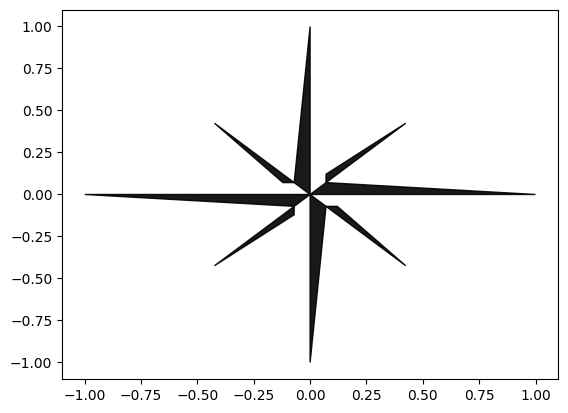

In [67]:
fig, ax = plt.subplots()
plot_polygon(compass, ax=ax, add_points=False, color='black', alpha=0.9)

plt.show()